# ATML Assignment 0 — Task 4: Variational Autoencoders

**Course:** EE-5102/CS-6304 Advanced Topics in Machine Learning


This notebook covers **Task 4** end-to-end: a basic MLP VAE on MNIST, latent-space
and reconstruction/generation analysis, and a comparison against Doersch's tutorial
implementation — including an empirical check of his claim that VAEs are "insensitive
to the dimensionality of z" outside extreme values.



## 0. Setup

In [1]:
import os, time, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
import torchvision.utils as vutils
from torchvision import datasets, transforms

print("torch:", torch.__version__, "| torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())


torch: 2.11.0+cu128 | torchvision: 0.26.0+cu128
CUDA available: True


In [2]:
from google.colab import drive
drive.mount('/content/drive')

ASSIGNMENT_BASE = "/content/drive/MyDrive/ATML_A0"
SHARED_DATA_DIR = os.path.join(ASSIGNMENT_BASE, "shared_data")
TASK_DIR        = os.path.join(ASSIGNMENT_BASE, "Task4_VAE")

CKPT_DIR   = os.path.join(TASK_DIR, "checkpoints")
LOG_DIR    = os.path.join(TASK_DIR, "logs")
FIG_DIR    = os.path.join(TASK_DIR, "figures")
MNIST_DIR  = os.path.join(SHARED_DATA_DIR, "mnist")

for d in [SHARED_DATA_DIR, CKPT_DIR, LOG_DIR, FIG_DIR, MNIST_DIR]:
    os.makedirs(d, exist_ok=True)

print("Task artifacts will persist under:", TASK_DIR)


Mounted at /content/drive
Task artifacts will persist under: /content/drive/MyDrive/ATML_A0/Task4_VAE


In [3]:
# ----------------------------- CONFIG --------------------------------------
SEED = 42
BATCH_SIZE = 128
NUM_EPOCHS = 20
HIDDEN_DIM = 400
LR = 1e-3

LATENT_DIM_PRIMARY = 2          # used for Part 2 (visualization, reconstruction, generation)
LATENT_DIMS_EXTRA  = [10, 20]   # extra runs for the Part 3 dimensionality comparison
# -----------------------------------------------------------------------------

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

set_seed(SEED)
DEVICE = get_device()
print("Using device:", DEVICE)


Using device: cuda


## 1. Checkpoint / logging utilities

Same pattern as the Task 1 notebook.

In [4]:
def save_checkpoint(state: dict, ckpt_path: str):
    tmp_path = ckpt_path + ".tmp"
    torch.save(state, tmp_path)
    os.replace(tmp_path, ckpt_path)

def load_checkpoint(ckpt_path: str, map_location=None):
    if os.path.exists(ckpt_path):
        return torch.load(ckpt_path, map_location=map_location)
    return None

def append_history_row(csv_path: str, row: dict):
    df_row = pd.DataFrame([row])
    header = not os.path.exists(csv_path)
    df_row.to_csv(csv_path, mode="a", header=header, index=False)

def load_history(csv_path: str) -> pd.DataFrame:
    if os.path.exists(csv_path):
        return pd.read_csv(csv_path)
    return pd.DataFrame(columns=["epoch", "train_loss", "train_recon", "train_kl",
                                  "val_loss", "val_recon", "val_kl", "time_sec"])


## 2. Data — MNIST

In [5]:
mnist_tf = transforms.ToTensor()   # keeps pixels in [0, 1], no normalization (Bernoulli likelihood)

train_set = datasets.MNIST(root=MNIST_DIR, train=True,  download=True, transform=mnist_tf)
test_set  = datasets.MNIST(root=MNIST_DIR, train=False, download=True, transform=mnist_tf)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"train={len(train_set)}  test={len(test_set)}")


train=60000  test=10000


## 3. Part 1 — Building a Basic VAE

MLP encoder → (μ, log σ²) → reparameterization trick → MLP decoder → per-pixel
Bernoulli parameters (sigmoid output). Loss is the negative ELBO: binary
cross-entropy reconstruction term + closed-form Gaussian KL term.

In [6]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=2):
        super().__init__()
        self.latent_dim = latent_dim
        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        # Decoder
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x_flat):
        h = F.relu(self.fc1(x_flat))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h))   # Bernoulli pixel probabilities

    def forward(self, x):
        x_flat = x.view(x.size(0), -1)
        mu, logvar = self.encode(x_flat)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar


def vae_loss(recon_x, x, mu, logvar):
    """Negative ELBO = reconstruction BCE (summed over pixels+batch) + closed-form
    Gaussian KL. Returned as (total, recon, kl), each summed over the batch — the
    training loop divides by batch size to report a per-example average."""
    x_flat = x.view(x.size(0), -1)
    recon_loss = F.binary_cross_entropy(recon_x, x_flat, reduction="sum")
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl, recon_loss, kl


In [7]:
def train_one_epoch_vae(model, loader, optimizer, device):
    model.train()
    total_loss, total_recon, total_kl, n = 0.0, 0.0, 0.0, 0
    for x, _ in loader:
        x = x.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = model(x)
        loss, recon_loss, kl = vae_loss(recon, x, mu, logvar)
        loss.backward()
        optimizer.step()
        bs = x.size(0)
        total_loss += loss.item(); total_recon += recon_loss.item(); total_kl += kl.item()
        n += bs
    return total_loss / n, total_recon / n, total_kl / n

@torch.no_grad()
def evaluate_vae(model, loader, device):
    model.eval()
    total_loss, total_recon, total_kl, n = 0.0, 0.0, 0.0, 0
    for x, _ in loader:
        x = x.to(device)
        recon, mu, logvar = model(x)
        loss, recon_loss, kl = vae_loss(recon, x, mu, logvar)
        bs = x.size(0)
        total_loss += loss.item(); total_recon += recon_loss.item(); total_kl += kl.item()
        n += bs
    return total_loss / n, total_recon / n, total_kl / n


In [8]:
def run_training_vae(run_name, model, train_loader, val_loader, optimizer, num_epochs,
                      ckpt_dir=CKPT_DIR, log_dir=LOG_DIR, device=None):
    """Resumable training loop: re-running with the same run_name picks up from the
    next un-trained epoch, or reloads history instantly if already finished."""
    device = device or get_device()
    model = model.to(device)

    ckpt_path = os.path.join(ckpt_dir, f"{run_name}.pt")
    history_path = os.path.join(log_dir, f"{run_name}_history.csv")

    start_epoch = 0
    ckpt = load_checkpoint(ckpt_path, map_location=device)
    if ckpt is not None:
        model.load_state_dict(ckpt["model_state"])
        optimizer.load_state_dict(ckpt["optimizer_state"])
        start_epoch = ckpt["epoch"] + 1
        print(f"[{run_name}] Resuming from epoch {start_epoch}/{num_epochs}")
    else:
        print(f"[{run_name}] No checkpoint found — starting fresh")

    for epoch in range(start_epoch, num_epochs):
        t0 = time.time()
        train_loss, train_recon, train_kl = train_one_epoch_vae(model, train_loader, optimizer, device)
        val_loss, val_recon, val_kl = evaluate_vae(model, val_loader, device)
        dt = time.time() - t0

        row = {"epoch": epoch, "train_loss": train_loss, "train_recon": train_recon, "train_kl": train_kl,
               "val_loss": val_loss, "val_recon": val_recon, "val_kl": val_kl, "time_sec": dt}
        append_history_row(history_path, row)
        print(f"[{run_name}] epoch {epoch}: train_elbo={train_loss:.2f} "
              f"(recon={train_recon:.2f} kl={train_kl:.2f})  val_elbo={val_loss:.2f}  ({dt:.1f}s)")

        state = {"epoch": epoch, "model_state": model.state_dict(), "optimizer_state": optimizer.state_dict()}
        save_checkpoint(state, ckpt_path)

    return load_history(history_path)


def plot_history(history_dfs: dict, metric: str, title: str, save_path=None):
    plt.figure(figsize=(6, 4))
    for label, df in history_dfs.items():
        plt.plot(df["epoch"], df[metric], marker="o", label=label)
    plt.xlabel("Epoch"); plt.ylabel(metric); plt.title(title)
    plt.legend(); plt.grid(alpha=0.3)
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


In [9]:
model_2d = VAE(input_dim=784, hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM_PRIMARY)
optimizer_2d = torch.optim.Adam(model_2d.parameters(), lr=LR)

history_2d = run_training_vae(
    run_name=f"vae_latent{LATENT_DIM_PRIMARY}",
    model=model_2d,
    train_loader=train_loader,
    val_loader=test_loader,
    optimizer=optimizer_2d,
    num_epochs=NUM_EPOCHS,
    device=DEVICE,
)
history_2d


[vae_latent2] Resuming from epoch 20/20


,epoch,train_loss,train_recon,train_kl,val_loss,val_recon,val_kl,time_sec
0,0,191.361238,185.521809,5.839429,171.758748,165.977252,5.781497,9.190371
1,1,168.363270,162.952651,5.410619,165.127714,159.655991,5.471723,9.494483
2,2,163.712320,158.173419,5.538901,162.242414,156.660814,5.581600,10.008476
3,3,161.129786,155.519941,5.609846,160.029872,154.201759,5.828113,8.067275
4,4,159.324119,153.624295,5.699824,158.778747,152.995236,5.783512,9.489007
5,5,157.969460,152.220599,5.748861,157.481943,151.579675,5.902268,9.877804
6,6,156.903532,151.097317,5.806215,157.035893,151.259548,5.776345,8.310992
7,7,156.031034,150.186018,5.845017,155.954621,150.187557,5.767064,9.471812
8,8,155.210346,149.319344,5.891002,155.310894,149.422625,5.888269,9.206290
9,9,154.538981,148.593638,5.945343,154.997018,149.221965,5.775053,8.652392


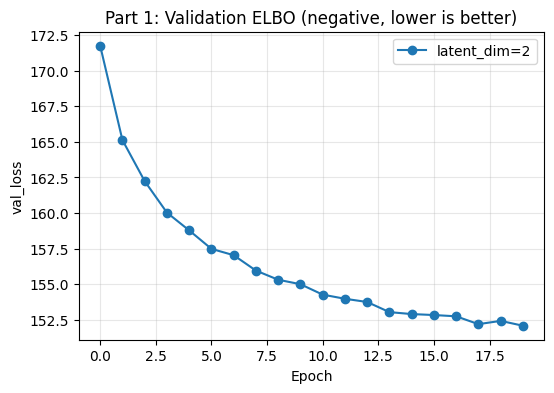

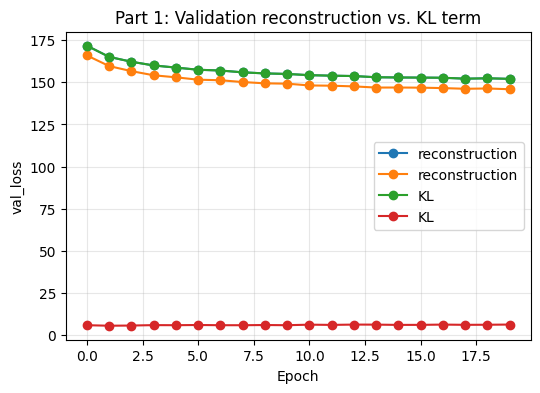

In [10]:
plot_history({"latent_dim=2": history_2d}, "val_loss", "Part 1: Validation ELBO (negative, lower is better)",
             save_path=os.path.join(FIG_DIR, "part1_val_elbo.png"))
plot_history({"reconstruction": history_2d.rename(columns={"val_recon": "val_loss"}),
              "KL": history_2d.rename(columns={"val_kl": "val_loss"})},
             "val_loss", "Part 1: Validation reconstruction vs. KL term",
             save_path=os.path.join(FIG_DIR, "part1_val_recon_vs_kl.png"))


## 4. Part 2 — Analyzing VAE Performance

### 2(a) Latent space visualization

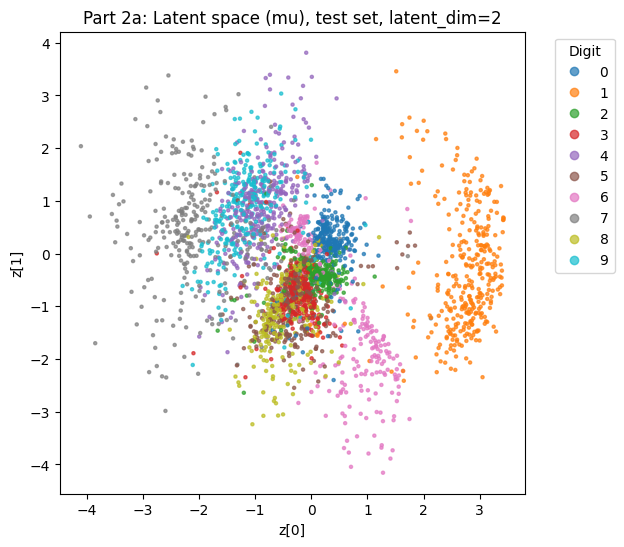

In [11]:
@torch.no_grad()
def get_latent_means(model, loader, device, max_samples=3000):
    model.eval()
    mus, labels = [], []
    collected = 0
    for x, y in loader:
        if collected >= max_samples:
            break
        x = x.to(device)
        mu, _ = model.encode(x.view(x.size(0), -1))
        mus.append(mu.cpu().numpy())
        labels.append(y.numpy())
        collected += x.size(0)
    return np.concatenate(mus)[:max_samples], np.concatenate(labels)[:max_samples]

mus2d, labels2d = get_latent_means(model_2d, test_loader, DEVICE, max_samples=3000)

plt.figure(figsize=(6, 6))
scatter = plt.scatter(mus2d[:, 0], mus2d[:, 1], c=labels2d, cmap="tab10", s=5, alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Digit", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xlabel("z[0]"); plt.ylabel("z[1]")
plt.title("Part 2a: Latent space (mu), test set, latent_dim=2")
plt.savefig(os.path.join(FIG_DIR, "part2a_latent_space.png"), dpi=150, bbox_inches="tight")
plt.show()


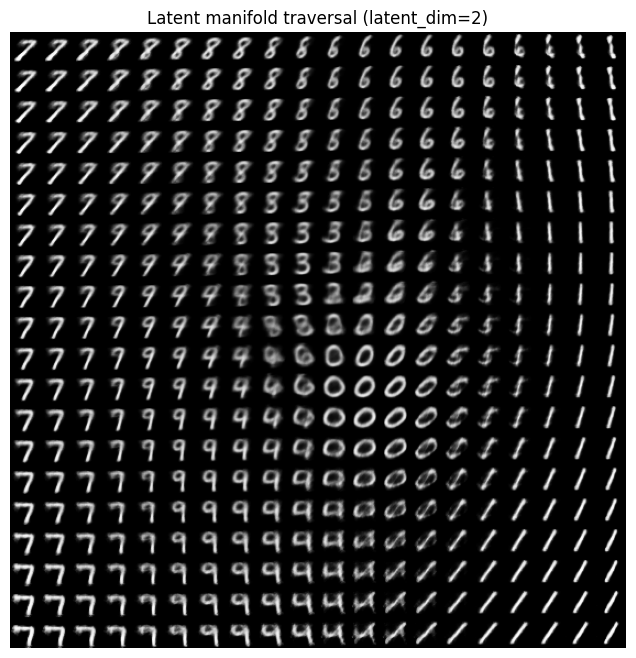

In [12]:
@torch.no_grad()
def plot_latent_manifold(model, device, grid_size=20, span=3.0, save_path=None):
    """Decode a regular grid of z values across the 2D latent space — a classic VAE
    visualization that directly shows whether the manifold is continuous (smooth
    digit-to-digit morphing) rather than a set of disconnected clusters."""
    model.eval()
    grid_x = np.linspace(-span, span, grid_size)
    grid_y = np.linspace(-span, span, grid_size)
    canvas = np.zeros((28 * grid_size, 28 * grid_size))
    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z = torch.tensor([[xi, yi]], dtype=torch.float32, device=device)
            img = model.decode(z).view(28, 28).cpu().numpy()
            canvas[i * 28:(i + 1) * 28, j * 28:(j + 1) * 28] = img
    plt.figure(figsize=(8, 8))
    plt.imshow(canvas, cmap="gray")
    plt.axis("off")
    plt.title("Latent manifold traversal (latent_dim=2)")
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

plot_latent_manifold(model_2d, DEVICE, save_path=os.path.join(FIG_DIR, "part2a_latent_manifold.png"))


**Discussion (for the report — Part 2a).**
Fill in against the scatter plot and manifold grid above: do same-digit points form
identifiable clusters even though the model never saw labels during training (it
shouldn't be perfectly separated — the VAE optimizes reconstruction + a KL term
toward an *isotropic Gaussian prior*, not class separability)? On the manifold grid,
look for smooth topological structure — visually similar digits (e.g. 4/9, 3/8) should
sit near each other with continuous, plausible-looking interpolations in between,
rather than the grid jumping abruptly from one digit to an unrelated one.

### 2(b) Reconstruction quality

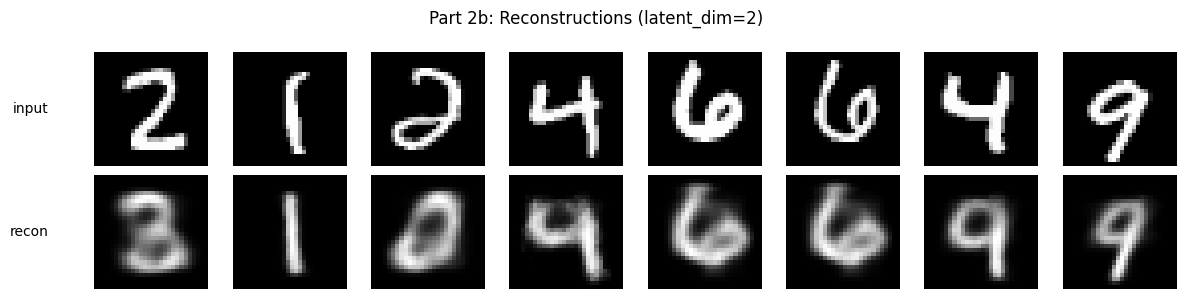

In [13]:
@torch.no_grad()
def show_reconstructions(model, dataset, device, n=8, seed=SEED, save_path=None, title=None):
    model.eval()
    rng = random.Random(seed)
    idx = rng.sample(range(len(dataset)), n)
    imgs = torch.stack([dataset[i][0] for i in idx]).to(device)
    mu, _ = model.encode(imgs.view(n, -1))
    recon = model.decode(mu).view(n, 1, 28, 28).cpu()

    fig, axes = plt.subplots(2, n, figsize=(1.5 * n, 3))
    for i in range(n):
        axes[0, i].imshow(imgs[i, 0].cpu(), cmap="gray"); axes[0, i].axis("off")
        axes[1, i].imshow(recon[i, 0], cmap="gray"); axes[1, i].axis("off")
    axes[0, 0].text(-0.4, 0.5, "input", transform=axes[0, 0].transAxes, va="center", ha="right")
    axes[1, 0].text(-0.4, 0.5, "recon", transform=axes[1, 0].transAxes, va="center", ha="right")
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

show_reconstructions(model_2d, test_set, DEVICE, n=8,
                      title="Part 2b: Reconstructions (latent_dim=2)",
                      save_path=os.path.join(FIG_DIR, "part2b_reconstructions.png"))


**Discussion (for the report — Part 2b).**
With only 2 latent dimensions the reconstructions will typically look noticeably
blurred and may lose fine stroke detail — a 2D bottleneck is a very aggressive
compression of a 784-pixel image, so this is expected, not a bug. Note which digits
reconstruct crisply vs. which come out ambiguous or morph toward a different digit —
that's useful material for the Part 3 comparison against Doersch below.

### 2(c) Generation of new samples

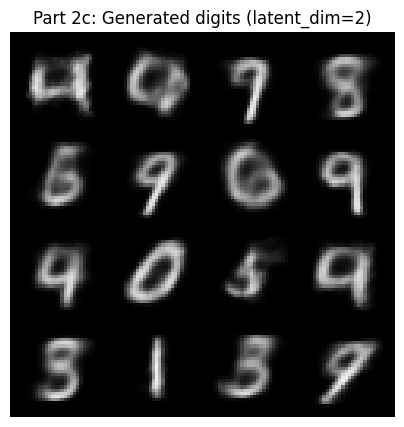

In [14]:
@torch.no_grad()
def generate_samples(model, latent_dim, device, n=16, seed=SEED, save_path=None, title=None):
    model.eval()
    torch.manual_seed(seed)
    z = torch.randn(n, latent_dim, device=device)
    samples = model.decode(z).view(n, 1, 28, 28).cpu()
    grid = vutils.make_grid(samples, nrow=int(math.sqrt(n)), padding=2)
    plt.figure(figsize=(5, 5))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.axis("off")
    plt.title(title or f"Samples from prior N(0, I) — latent_dim={latent_dim}")
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

generate_samples(model_2d, LATENT_DIM_PRIMARY, DEVICE, n=16,
                  title="Part 2c: Generated digits (latent_dim=2)",
                  save_path=os.path.join(FIG_DIR, "part2c_generated_samples.png"))


**Discussion (for the report — Part 2c).**
Most samples should look like plausible, if somewhat blurry, digits — evidence the
prior actually covers the region of latent space the decoder was trained to interpret,
rather than the model having collapsed to memorizing training examples. Flag any
samples that look like an ambiguous blend of two digits (a common VAE artifact,
especially with a low-dimensional bottleneck) — Doersch notes exactly this kind of
"in-between" digit in his own tutorial, which is a natural point of comparison.

## 5. Part 3 — Comparing with Doersch's VAE Implementation

Two extra models (`latent_dim=10` and `latent_dim=20`) are trained here — same
architecture and loss, only the bottleneck width changes — to empirically check
Doersch's claim that VAE performance is "insensitive to the dimensionality of z" in a
broad range, and to compare reconstruction quality/training difficulty across widths.

In [15]:
models_by_dim = {LATENT_DIM_PRIMARY: model_2d}
histories_by_dim = {LATENT_DIM_PRIMARY: history_2d}

for dim in LATENT_DIMS_EXTRA:
    m = VAE(input_dim=784, hidden_dim=HIDDEN_DIM, latent_dim=dim)
    opt = torch.optim.Adam(m.parameters(), lr=LR)
    hist = run_training_vae(
        run_name=f"vae_latent{dim}",
        model=m,
        train_loader=train_loader,
        val_loader=test_loader,
        optimizer=opt,
        num_epochs=NUM_EPOCHS,
        device=DEVICE,
    )
    models_by_dim[dim] = m
    histories_by_dim[dim] = hist


[vae_latent10] Resuming from epoch 20/20
[vae_latent20] Resuming from epoch 20/20


In [16]:
summary_rows = []
for dim, hist in histories_by_dim.items():
    final = hist.iloc[-1]
    summary_rows.append({"latent_dim": dim, "val_elbo": final["val_loss"],
                          "val_recon": final["val_recon"], "val_kl": final["val_kl"]})

summary_df = pd.DataFrame(summary_rows).sort_values("latent_dim").reset_index(drop=True)
summary_df.to_csv(os.path.join(LOG_DIR, "part3_latent_dim_comparison.csv"), index=False)
summary_df


,latent_dim,val_elbo,val_recon,val_kl
0,2,152.079294,145.912482,6.166812
1,10,107.557000,89.073586,18.483414
2,20,103.853255,77.826432,26.026823


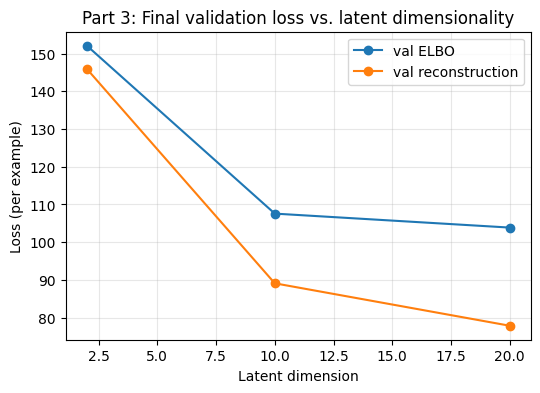

In [17]:
plt.figure(figsize=(6, 4))
plt.plot(summary_df["latent_dim"], summary_df["val_elbo"], marker="o", label="val ELBO")
plt.plot(summary_df["latent_dim"], summary_df["val_recon"], marker="o", label="val reconstruction")
plt.xlabel("Latent dimension"); plt.ylabel("Loss (per example)")
plt.title("Part 3: Final validation loss vs. latent dimensionality")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(os.path.join(FIG_DIR, "part3_loss_vs_latent_dim.png"), dpi=150, bbox_inches="tight")
plt.show()


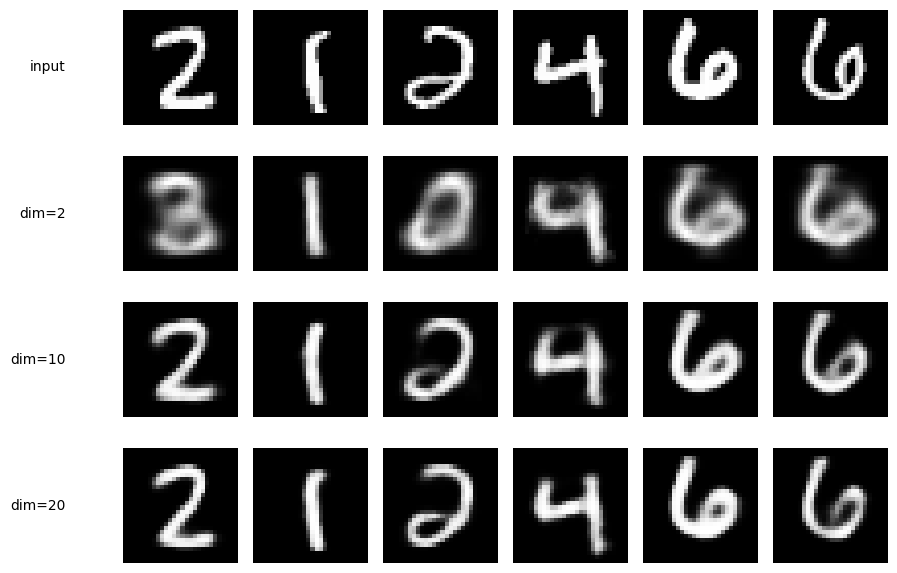

In [18]:
def show_reconstructions_multi(models_by_dim, dataset, device, n=6, seed=SEED, save_path=None):
    rng = random.Random(seed)
    idx = rng.sample(range(len(dataset)), n)
    imgs = torch.stack([dataset[i][0] for i in idx]).to(device)

    dims_sorted = sorted(models_by_dim.keys())
    rows = 1 + len(dims_sorted)
    fig, axes = plt.subplots(rows, n, figsize=(1.5 * n, 1.5 * rows))

    for j in range(n):
        axes[0, j].imshow(imgs[j, 0].cpu(), cmap="gray"); axes[0, j].axis("off")
    axes[0, 0].text(-0.5, 0.5, "input", transform=axes[0, 0].transAxes, va="center", ha="right")

    for r, dim in enumerate(dims_sorted, start=1):
        model = models_by_dim[dim]
        model.eval()
        with torch.no_grad():
            mu, _ = model.encode(imgs.view(n, -1))
            recon = model.decode(mu).view(n, 1, 28, 28).cpu()
        for j in range(n):
            axes[r, j].imshow(recon[j, 0], cmap="gray"); axes[r, j].axis("off")
        axes[r, 0].text(-0.5, 0.5, f"dim={dim}", transform=axes[r, 0].transAxes, va="center", ha="right")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

show_reconstructions_multi(models_by_dim, test_set, DEVICE, n=6,
                            save_path=os.path.join(FIG_DIR, "part3_reconstructions_by_dim.png"))


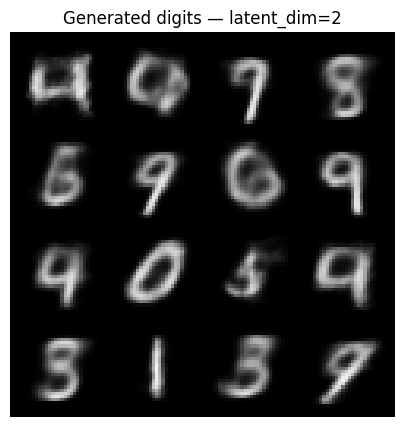

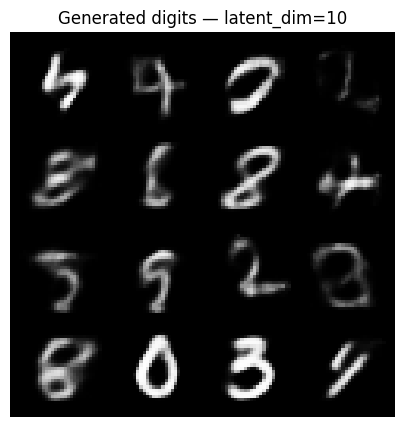

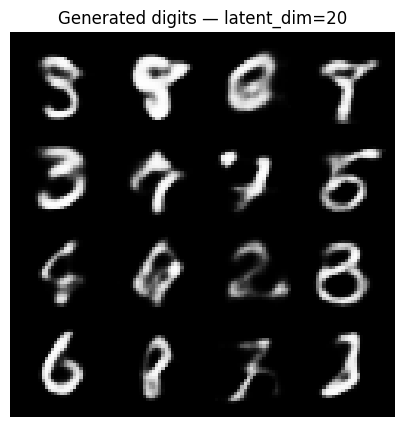

In [19]:
for dim, model in sorted(models_by_dim.items()):
    generate_samples(model, dim, DEVICE, n=16, title=f"Generated digits — latent_dim={dim}",
                      save_path=os.path.join(FIG_DIR, f"part3_generated_dim{dim}.png"))


**Discussion (for the report — Part 3).**

*Architecture.* This notebook uses a single-hidden-layer MLP (784 → 400 → latent →
400 → 784) for both encoder and decoder, matching the general shape the assignment
points to (Doersch's tutorial and repo use a comparably simple MLP on MNIST — check
his actual code at the linked repo for the exact unit count he used, and note it here
alongside the 400 used here).

*Output distribution and loss.* Both this implementation and Doersch's treat MNIST
pixel intensities as Bernoulli parameters and use a sigmoid output with a
binary-cross-entropy reconstruction term (equivalently, sigmoid cross-entropy) — the
same choice made here, so this dimension of the comparison should match directly.

*Latent dimensionality.* Compare the `val_elbo`/`val_recon` numbers in the summary
table above across `latent_dim ∈ {2, 10, 20}`. Doersch's claim is that the VAE is fairly
insensitive to z's dimensionality across a broad middle range, degrading mainly at the
extremes (too small to encode enough information, or so large the KL term dominates
and/or optimization gets harder). With only three points here (2, 10, 20) you're
sampling the "small" end of that range — 2 is likely visibly worse on reconstruction
than 10 or 20 (as seen in the reconstruction grid above), while 10 vs. 20 should be
much closer to each other, which is broadly consistent with his claim; if you want a
sharper test of "insensitivity," add a much larger `latent_dim` (e.g. 50+) to
`LATENT_DIMS_EXTRA` and see whether it actually gets worse.

*Results comparison.* Compare your generated-sample grids across dimensions above with
the samples Doersch shows in the tutorial — note any shared failure modes, in
particular digits that come out as an ambiguous blend of two classes (most likely to
show up at `latent_dim=2`), and whether that failure mode disappears at higher
dimensions.

---
### Report checklist
- [ ] VAE architecture, loss derivation, and training curves — Part 1
- [ ] Latent-space scatter + manifold traversal — Part 2a
- [ ] Reconstruction grid + discussion — Part 2b
- [ ] Generated-sample grid + discussion — Part 2c
- [ ] Latent-dimension comparison table/plot + Doersch comparison — Part 3
- [ ] Push notebook + all figures/CSVs to the public GitHub repo
